# Actividad 4 — Calidad · INDECI

**Objetivo:** Auditar la calidad de los shapefiles INDECI: nulos, formato de la columna mes, fenomenos fuera del catalogo, cobertura temporal y consistencia con los resumenes Excel.


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings, unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']

def normalizar(t):
    if not isinstance(t, str): return ''
    t = unicodedata.normalize('NFKD', t).encode('ASCII','ignore').decode('utf-8')
    return t.upper().strip()

def reporte_nulos(df, nombre):
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    r = pd.DataFrame({'nulos': nulos, 'pct': pct})
    r = r[r['nulos'] > 0].sort_values('nulos', ascending=False)
    print(f'=== NULOS EN {nombre} ===')
    if len(r) == 0:
        print('  Sin valores nulos.')
    else:
        print(r.to_string())
    print()
    return r

def outliers_iqr(serie, nombre):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (serie < lower) | (serie > upper)
    n_out = mask.sum()
    pct = n_out / len(serie) * 100
    print(f'{nombre}: Q1={Q1:.2f} Q3={Q3:.2f} IQR={IQR:.2f}')
    print(f'  Limite inferior: {lower:.2f} | Limite superior: {upper:.2f}')
    print(f'  Outliers: {n_out} ({pct:.2f}%)')
    return lower, upper, mask

print('Config cargado OK | Raiz:', os.getcwd())


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## Carga de datos


In [2]:
import geopandas as gpd

MESES_ES = {'ENERO':1,'FEBRERO':2,'MARZO':3,'ABRIL':4,'MAYO':5,'JUNIO':6,
            'JULIO':7,'AGOSTO':8,'SETIEMBRE':9,'SEPTIEMBRE':9,'OCTUBRE':10,
            'NOVIEMBRE':11,'DICIEMBRE':12}

dfs_shp = []
for d in sorted(glob.glob(SOURCES['indeci_shapefiles'] + 'E_*/')):
    shp = glob.glob(d + '*.shp')
    if shp:
        gdf = gpd.read_file(shp[0])
        df_tmp = pd.DataFrame(gdf.drop(columns='geometry', errors='ignore'))
        df_tmp.columns = [str(c).lower() for c in df_tmp.columns]
        dfs_shp.append(df_tmp)
df_indeci = pd.concat(dfs_shp, ignore_index=True)
print(f'Dataset INDECI: {df_indeci.shape}')
print(f'Columnas: {df_indeci.columns.tolist()[:12]}')


Dataset INDECI: (25025, 79)
Columnas: ['ide_sinpad', 'fecha', 'anho', 'mes', 'cod_ubigeo', 'departamen', 'provincia', 'distrito', 'fenomeno', 'region', 'safecta', 'sdamni']


## 4.1 Auditoria de Nulos en Columnas Clave


=== NULOS EN COLUMNAS CLAVE INDECI ===
  fenomeno                  0 nulos (0.00%)  [OK]
  departamen                0 nulos (0.00%)  [OK]
  provincia                 0 nulos (0.00%)  [OK]
  anho                      0 nulos (0.00%)  [OK]
  mes                       0 nulos (0.00%)  [OK]


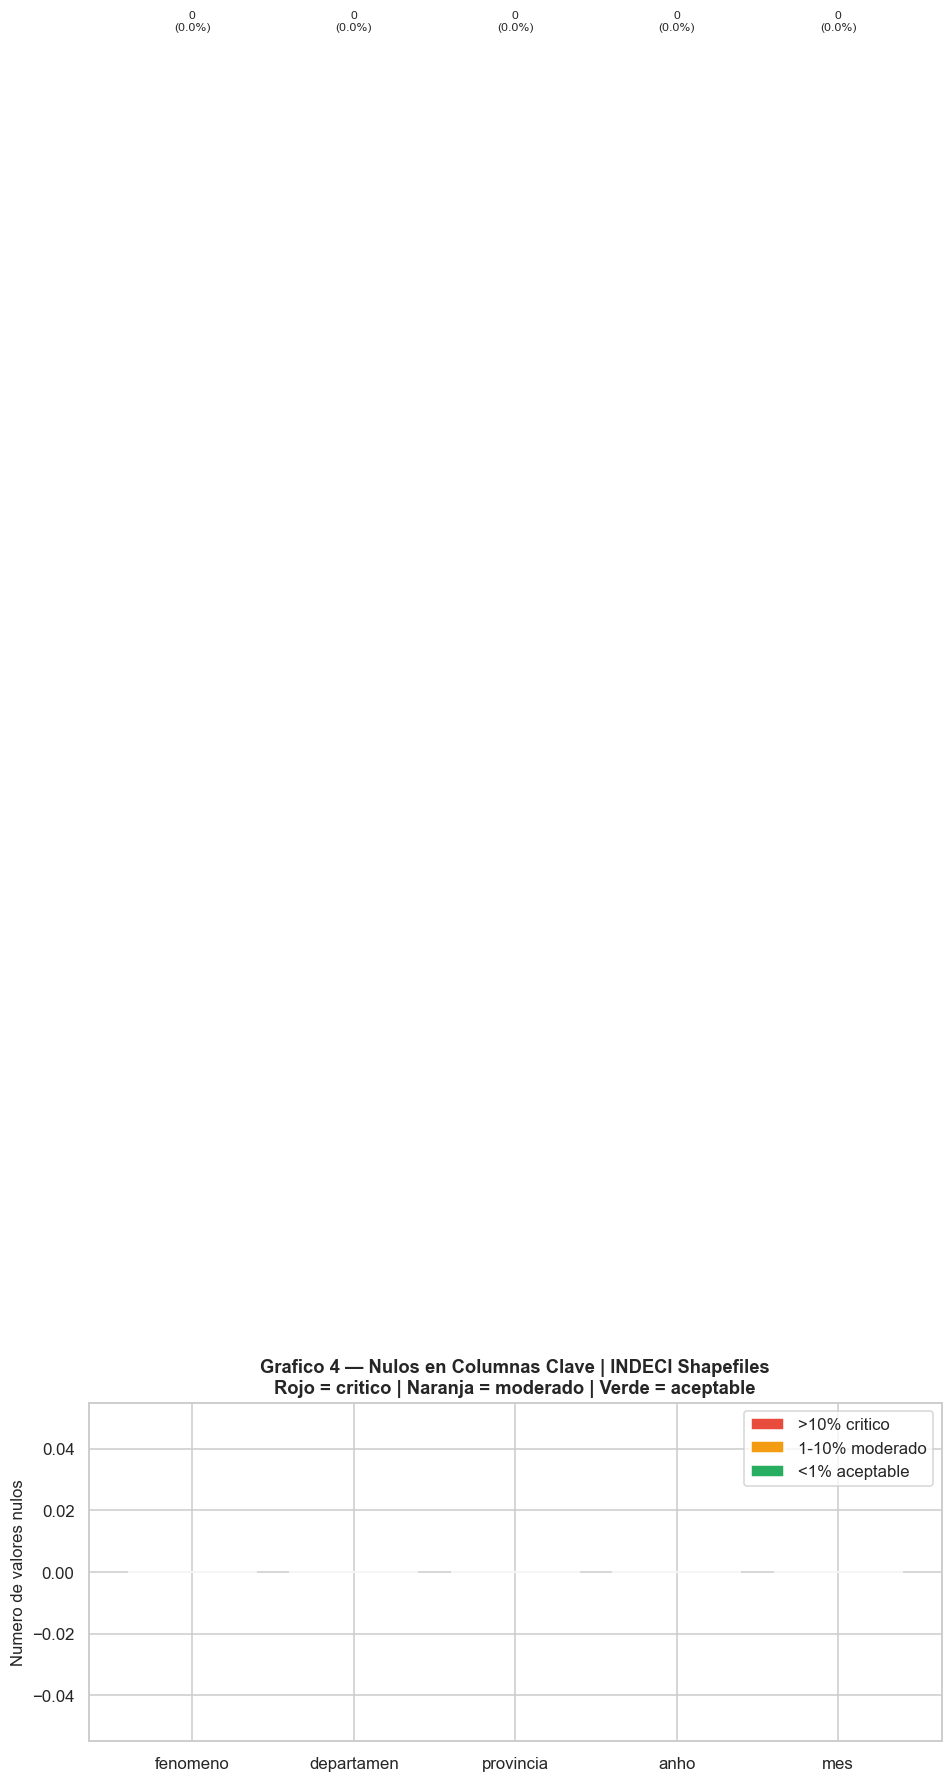

Guardado: pipeline/output/04_calidad/act04_indeci_g4_nulos.png


In [3]:
cols_clave = ['fenomeno','departamen','provincia','anho','mes']
cols_clave = [c for c in cols_clave if c in df_indeci.columns]

nulos_clave = df_indeci[cols_clave].isnull().sum()
pct_clave   = (nulos_clave / len(df_indeci) * 100).round(2)

print('=== NULOS EN COLUMNAS CLAVE INDECI ===')
for col, n, p in zip(nulos_clave.index, nulos_clave.values, pct_clave.values):
    nivel = 'CRITICO' if p > 10 else 'MODERADO' if p > 1 else 'OK'
    print(f'  {col:<20} {n:>6,} nulos ({p:.2f}%)  [{nivel}]')

# Grafico G4
fig, ax = plt.subplots(figsize=(10, 4))
colors_n = ['#e74c3c' if p > 10 else '#f39c12' if p > 1 else '#27ae60'
            for p in pct_clave.values]
bars = ax.bar(nulos_clave.index, nulos_clave.values, color=colors_n, edgecolor='white')
for bar, val, p in zip(bars, nulos_clave.values, pct_clave.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Numero de valores nulos', fontsize=11)
ax.set_title('Grafico 4 — Nulos en Columnas Clave | INDECI Shapefiles\n'
             'Rojo = critico | Naranja = moderado | Verde = aceptable',
             fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='>10% critico'),
                   Patch(facecolor='#f39c12', label='1-10% moderado'),
                   Patch(facecolor='#27ae60', label='<1% aceptable')])
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_indeci_g4_nulos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Nulos en columnas clave (fenomeno, departamento, fecha)  
**Magnitud:** Ver tabla de nulos arriba  
**Decision (Actividad 5):** En la Actividad 5 se eliminaran las filas con nulos en columnas clave (fenomeno, departamento, anho).


## 4.2 Formato de la Columna Mes (texto vs numero)


=== AUDITORIA COLUMNA MES ===
Valores unicos en columna mes: 12

Distribucion de valores:
mes
ABRIL        2011
AGOSTO       1473
DICIEMBRE     618
ENERO        3767
FEBRERO      4030
JULIO        1140
JUNIO        1129
MARZO        3690
MAYO         1113
NOVIEMBRE    2333
OCTUBRE      1961
SETIEMBRE    1760

Columna mes contiene texto (nombres de meses): True


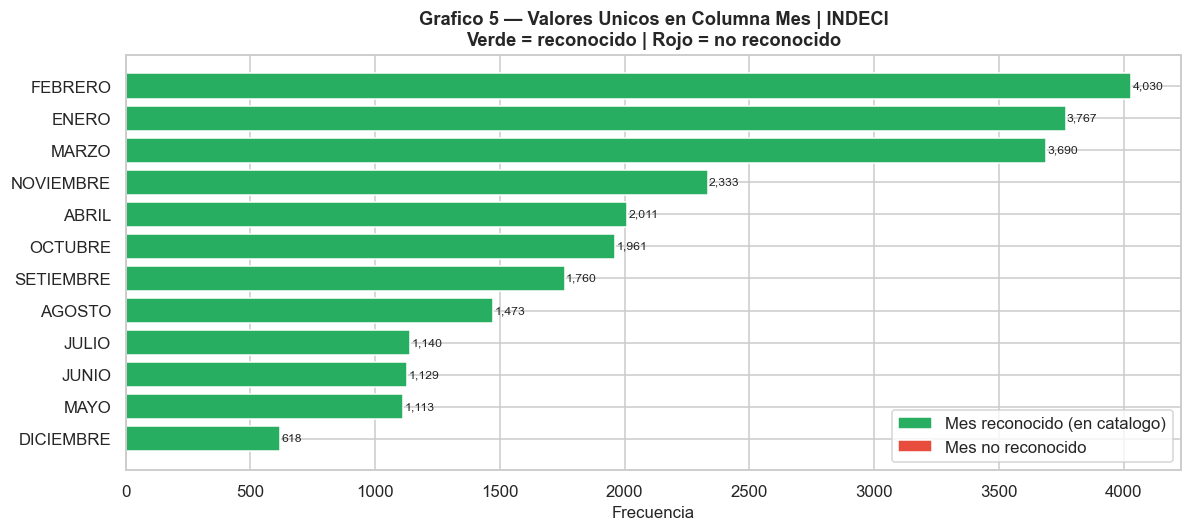

Guardado: pipeline/output/04_calidad/act04_indeci_g5_mes.png


In [4]:
print('=== AUDITORIA COLUMNA MES ===')
valores_mes = df_indeci['mes'].value_counts().sort_index()
print(f'Valores unicos en columna mes: {df_indeci["mes"].nunique()}')
print()
print('Distribucion de valores:')
print(valores_mes.to_string())
print()

# Verificar si son texto o numero
es_texto = df_indeci['mes'].apply(lambda x: isinstance(x, str) and not str(x).isdigit()).any()
print(f'Columna mes contiene texto (nombres de meses): {es_texto}')

# Grafico G5: distribucion de valores en mes
fig, ax = plt.subplots(figsize=(11, 5))
valores_mes_plot = valores_mes.sort_values(ascending=True)
colors_mes = ['#27ae60' if str(v).upper() in MESES_ES else '#e74c3c'
              for v in valores_mes_plot.index]
ax.barh(valores_mes_plot.index.astype(str), valores_mes_plot.values,
        color=colors_mes, edgecolor='white')
for i, val in enumerate(valores_mes_plot.values):
    ax.text(val+5, i, f'{int(val):,}', va='center', fontsize=8)
ax.set_xlabel('Frecuencia', fontsize=11)
ax.set_title('Grafico 5 — Valores Unicos en Columna Mes | INDECI\n'
             'Verde = reconocido | Rojo = no reconocido',
             fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#27ae60', label='Mes reconocido (en catalogo)'),
                   Patch(facecolor='#e74c3c', label='Mes no reconocido')])
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_indeci_g5_mes.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Columna mes en formato texto español (ENERO, FEBRERO...) en lugar de numero  
**Magnitud:** Todos los registros afectados — es el formato nativo del shapefile  
**Decision (Actividad 5):** En la Actividad 5 se aplicara un mapeo MESES_ES para convertir a numero (1-12).


## 4.3 Fenomenos Fuera del Catalogo


In [5]:
FENOMENOS_VALIDOS = [normalizar(f) for f in CONFIG['fenomenos_indeci']]
df_indeci['fenomeno_norm'] = df_indeci['fenomeno'].apply(normalizar)

en_catalogo = df_indeci['fenomeno_norm'].isin(FENOMENOS_VALIDOS)
fuera_catalogo = df_indeci[~en_catalogo]['fenomeno_norm'].value_counts()

print(f'Total registros: {len(df_indeci):,}')
print(f'En catalogo agricola: {en_catalogo.sum():,} ({en_catalogo.mean()*100:.1f}%)')
print(f'Fuera del catalogo: {(~en_catalogo).sum():,} ({(~en_catalogo).mean()*100:.1f}%)')
print()
print('Top 15 fenomenos fuera del catalogo:')
print(fuera_catalogo.head(15).to_string())
print()
print('Catalogo de fenomenos validos:')
print(FENOMENOS_VALIDOS)


Total registros: 25,025
En catalogo agricola: 13,487 (53.9%)
Fuera del catalogo: 11,538 (46.1%)

Top 15 fenomenos fuera del catalogo:
fenomeno_norm
INCENDIOS                           2368
INCENDIOS URBANOS                   2038
INCENDIOS FORESTALES                1553
GRANIZADAS                           679
PRECIPITACIONES - GRANIZO            657
TEMPORALES (VIENTOS CON LLUVIAS)     589
SISMOS                               521
HUAYCOS                              406
DEFICIT HIDRICO                      406
INUNDACION POR DESBORDE DE RIO       397
DERRUMBE CERROS                      381
DERRUMBES                            265
COLAPSO POR ANTIGUEDAD               241
PRECIPITACIONES - NEVADA             169
NEVADAS                              149

Catalogo de fenomenos validos:
['LLUVIAS INTENSAS', 'INUNDACION', 'HUAYCO', 'SEQUIA', 'HELADAS', 'FRIAJE', 'GRANIZADA', 'NEVADA', 'VIENTOS FUERTES', 'DESLIZAMIENTO', 'EROSION']


### Decision tecnica documentada

**Problema:** Registros con fenomenos no relevantes para agricultura (accidentes, incendios, etc.)  
**Magnitud:** Ver porcentaje fuera del catalogo arriba  
**Decision (Actividad 5):** En la Actividad 5 se filtrara el dataset conservando solo los fenomenos del catalogo agricola.


## 4.4 Cobertura Temporal por Año y Mes


Cobertura por año y mes:
mes_num     1     2     3     4    5    6    7    8    9     10    11   12
anho_int                                                                  
2021      1533  1407  1748  1054  608  529  560  823  890   852  1035  136
2022      1096  1485  1942   957  505  600  580  650  870  1109  1298  482
2023      1138  1138     0     0    0    0    0    0    0     0     0    0


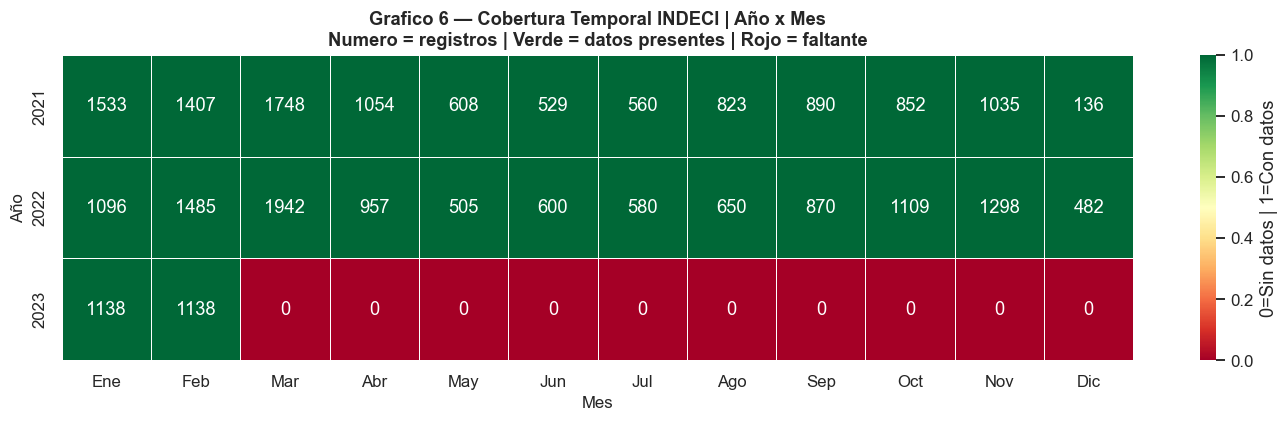

Guardado: pipeline/output/04_calidad/act04_indeci_g6_cobertura.png


In [6]:
# Mapear mes a numero
def mes_a_num(v):
    try:
        n = int(v)
        return n if 1 <= n <= 12 else None
    except (ValueError, TypeError):
        return MESES_ES.get(str(v).upper().strip(), None)

df_indeci['mes_num'] = df_indeci['mes'].apply(mes_a_num)
df_indeci['anho_int'] = pd.to_numeric(df_indeci['anho'], errors='coerce')

cobertura = df_indeci.groupby(['anho_int','mes_num']).size().unstack(fill_value=0)
cobertura_bool = (cobertura > 0).astype(int)

print('Cobertura por año y mes:')
print(cobertura.to_string())

# Grafico G6
fig, ax = plt.subplots(figsize=(13, 4))
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
cobertura_bool.columns = [meses_nombres[int(c)-1] if pd.notna(c) and 1<=int(c)<=12
                           else str(c) for c in cobertura_bool.columns]
sns.heatmap(cobertura_bool, annot=cobertura.values, fmt='d',
            cmap='RdYlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': '0=Sin datos | 1=Con datos'})
ax.set_title('Grafico 6 — Cobertura Temporal INDECI | Año x Mes\n'
             'Numero = registros | Verde = datos presentes | Rojo = faltante',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Año', fontsize=11)
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_indeci_g6_cobertura.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Cobertura temporal incompleta en algunos meses (shapefile E_2023 es parcial)  
**Magnitud:** Ver heatmap — meses faltantes en 2023  
**Decision (Actividad 5):** En la Actividad 6 se complementara con los resumenes Excel para los meses faltantes.


## 4.5 Consistencia Shapefiles vs Resumenes Excel


In [7]:
# Cargar resumen Excel para comparar totales
xlsx_files = glob.glob(SOURCES['indeci_resumenes'] + '*.xlsx')
print(f'Archivos Excel disponibles: {len(xlsx_files)}')
for f in xlsx_files:
    df_res = pd.read_excel(f, sheet_name=0)
    print(f'  {os.path.basename(f)}: {df_res.shape}')

print()
print(f'Total registros en shapefiles: {len(df_indeci):,}')
print(f'Años cubiertos en shapefiles: {sorted(df_indeci["anho_int"].dropna().unique().astype(int).tolist())}')

# Reporte de calidad INDECI
reporte = [
    'REPORTE DE CALIDAD — INDECI SHAPEFILES',
    '=' * 60,
    f'Registros totales: {len(df_indeci):,}',
    f'En catalogo agricola: {en_catalogo.sum():,} ({en_catalogo.mean()*100:.1f}%)',
    f'Fuera del catalogo: {(~en_catalogo).sum():,} ({(~en_catalogo).mean()*100:.1f}%)',
    f'Columna mes en texto: {es_texto}',
    f'Nulos en fenomeno: {df_indeci["fenomeno"].isnull().sum()}',
    f'Nulos en departamento: {df_indeci["departamen"].isnull().sum()}',
]
reporte_txt = '\n'.join(reporte)
print()
print(reporte_txt)
with open(OUTPUT['calidad'] + 'reporte_calidad_indeci.txt', 'w', encoding='utf-8') as f:
    f.write(reporte_txt)
print()
print('[ACTIVIDAD 4 - INDECI] COMPLETADA.')


Archivos Excel disponibles: 4
  piura_emergencias.xlsx: (100, 18)
  piura_peligros.xlsx: (114, 22)


  resumen_emergencias_2003_2024.xlsx: (35, 17)
  resumen_peligros_2003_2024.xlsx: (30, 28)

Total registros en shapefiles: 25,025
Años cubiertos en shapefiles: [2021, 2022, 2023]

REPORTE DE CALIDAD — INDECI SHAPEFILES
Registros totales: 25,025
En catalogo agricola: 13,487 (53.9%)
Fuera del catalogo: 11,538 (46.1%)
Columna mes en texto: True
Nulos en fenomeno: 0
Nulos en departamento: 0

[ACTIVIDAD 4 - INDECI] COMPLETADA.
